In [1]:
verbose = True

In [2]:
# All the imports

import torch
from torch.utils.data import TensorDataset
from torch import nn
import matplotlib.pyplot as plt

from load_dataset import labelList, get_data
from preprocess import preprocess_dataset
import bigmodel

from ml_util.eeg_util import plotEEG, plotTimeFreqEEG
from ml_util.checkpoint import checkpoint
from ml_util.data_module import DataModule, calculate_accuracy
from ml_util.trainer import Trainer
from ml_util.report_wandb import WandBReporter, print_stats

Loading dataset


                               | 0/480 [          ]

Dataset loaded, X : torch.Size([480, 32, 3200])


In [ ]:
X_raw, y = get_data(verbose=True)

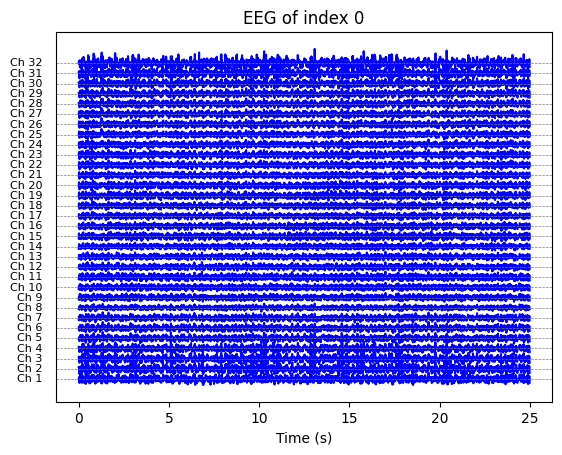

Arithmetic


In [3]:
if verbose:
    plotEEG(X_raw[0], title="index 0")
    print(labelList[y[0]])

In [4]:
# Applies preprocessing
X = checkpoint(lambda : preprocess_dataset(X_raw, verbose=True), "preprocessed")
print("Input dataset shape: {X.shape}")

# Stores in a TensorDataset
dataset = DataModule(X, y)

Batch function apply: 100%|█████████████████████| 15/15 [01:05<00:00,  4.35s/it]


torch.Size([480, 32, 32, 51])


<Figure size 640x480 with 0 Axes>

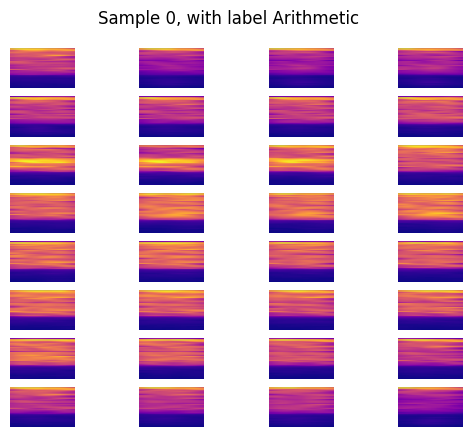

<Figure size 640x480 with 0 Axes>

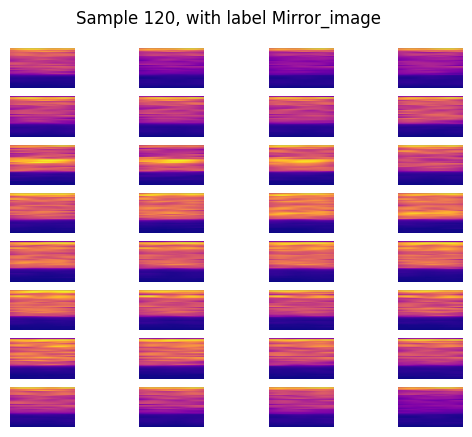

<Figure size 640x480 with 0 Axes>

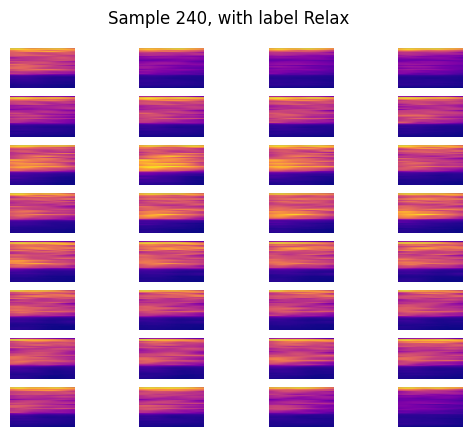

<Figure size 640x480 with 0 Axes>

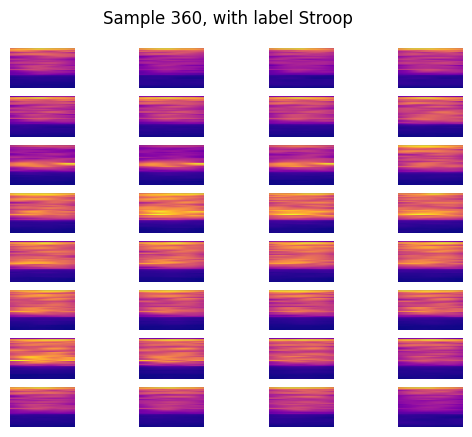

In [5]:
if verbose:
    for label in range(4):
        sampleId = torch.where(y==label)[0][0]
        plt.figure()
        fig, axes = plotTimeFreqEEG(X[sampleId])
        #plt.imshow(X[sampleId][0])
        fig.suptitle(f"Sample {sampleId}, with label {labelList[y[sampleId]]}")
    plt.show()

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU" if torch.cuda.is_available() else "CPU")

hyperparams = {
    'lr': 4e-3
    'weight_decay': 0
    'batch_size': 16
}
model = bigmodel.model(X[0])
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=hyperparams['lr'], weight_decay=hyperparams['weight_decay'])

trainer = Trainer(model, optimizer, loss_fn, hyperparams, device)

def babysitter(hyperparameters, epoch_results):
    hyperparameters['lr'] = 0.9 * hyperparameters['lr']

wandbreporter = WandBReporter(hyperparams)
def report(res):
    print_stats(res)
    wandbreporter.report(res)

trainer.set_report_callback(report)
trainer.set_babysitting_callback(babysitter)

CPU


wandb: Currently logged in as: ulyssedurand (ulyssedurand-ens-de-lyon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
trainer.train(dataset, 100)

Epoch:    0    | tl: 24.048435, ta: 0.250000    |    vl: 173.506866, va: 0.250000
Epoch:    1    | tl: 26.104347, ta: 0.187500    |    vl: 118.088593, va: 0.305556
Epoch:    2    | tl: 30.217407, ta: 0.250000    |    vl: 113.574615, va: 0.180556
Epoch:    3    | tl: 26.251022, ta: 0.187500    |    vl: 106.683868, va: 0.444444
Epoch:    4    | tl: 35.003120, ta: 0.500000    |    vl: 102.740494, va: 0.194444
Epoch:    5    | tl: 29.271290, ta: 0.375000    |    vl: 103.027115, va: 0.208333
Epoch:    6    | tl: 27.423773, ta: 0.250000    |    vl: 103.136566, va: 0.208333
Epoch:    7    | tl: 25.838905, ta: 0.125000    |    vl: 103.529541, va: 0.138889
Epoch:    8    | tl: 25.184593, ta: 0.125000    |    vl: 103.003975, va: 0.111111
Epoch:    9    | tl: 23.295317, ta: 0.062500    |    vl: 102.235939, va: 0.166667
Epoch:   10    | tl: 22.919098, ta: 0.125000    |    vl: 101.610634, va: 0.166667
Epoch:   11    | tl: 22.558422, ta: 0.187500    |    vl: 101.164421, va: 0.166667
Epoch:   12    |